# 淘宝直播带货场景用户行为分析
# Taobao Live Shopping User Behavior Analysis

## 0 数据清洗

In [1]:
import pandas as pd

# 读取数据（建议先抽100万条）
df = pd.read_csv('D:/TIANYU ZHAO FILE_____________/实习/UserBehavior.csv.zip', 
                 names=['user_id','item_id','category_id','behavior','timestamp'],
                 nrows=1000000)

# 时间戳转换
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s') + pd.Timedelta(hours=8)
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek

# 过滤异常时间（只保留数据集标注的时间范围）
df = df[(df['datetime'] >= '2017-11-25') & (df['datetime'] <= '2017-12-03')]

# 去重
df = df.drop_duplicates()

print(df['behavior'].value_counts())
print(df.shape)

D:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


behavior
pv      773193
cart     47668
fav      24270
buy      17754
Name: count, dtype: int64
(862885, 9)


## 模块一：直播时段识别与冲动消费分析

**分析目的**

将晚间20-22点定义为直播黄金时段，验证以下两个假设：
1. 直播时段是否带来更高的冲动购买率（pv直接转化为buy，跳过加购/收藏）
2. 直播时段的用户行为结构与非直播时段是否存在显著差异

**核心指标**
- 冲动购买率：有buy且有pv、但无cart和fav的购买行为占所有购买行为的比例
- 用户行为结构：冲动购买型/计划购买型/种草未购型/纯浏览型各自占比

### 0101定义黄金直播时段

C:\Windows\Temp\ipykernel_6124\3409667821.py:11: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  plt.savefig('output/charts/hourly_behavior.png')
C:\Windows\Temp\ipykernel_6124\3409667821.py:11: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from current font.
  plt.savefig('output/charts/hourly_behavior.png')
C:\Windows\Temp\ipykernel_6124\3409667821.py:11: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.savefig('output/charts/hourly_behavior.png')
C:\Windows\Temp\ipykernel_6124\3409667821.py:11: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from current font.
  plt.savefig('output/charts/hourly_behavior.png')
C:\Windows\Temp\ipykernel_6124\3409667821.py:11: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  plt.savefig('output/charts/hourly_behavior.png')
C:\Windows\Temp\ipykernel_6124\3409667821.py:11: UserWarning: Glyph 34892 (

直播时段转化率: 0.0195
非直播时段转化率: 0.0241
提升幅度: -18.9%


D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabt

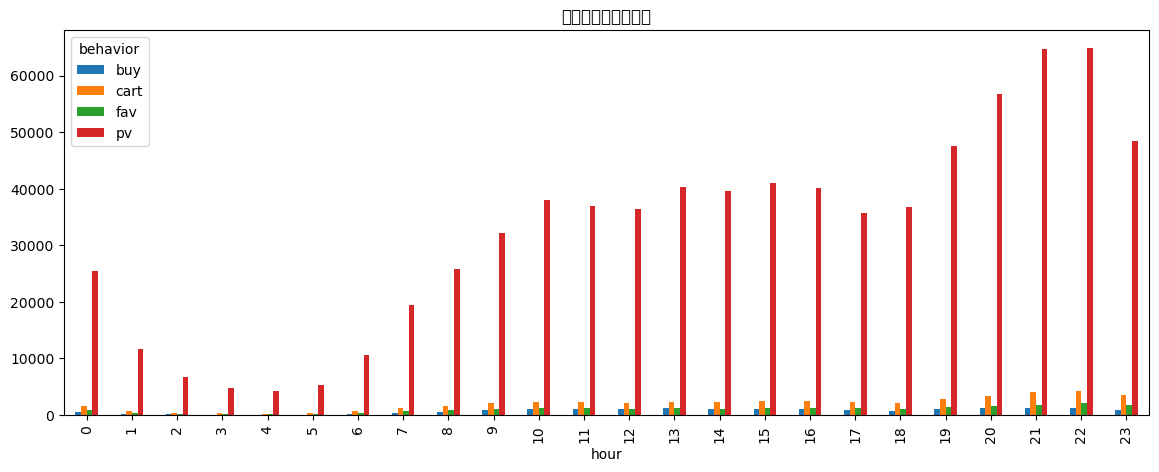

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('output/charts', exist_ok=True)
# 定义直播黄金时段：晚上20-22点
df['is_live_hour'] = df['hour'].isin([20, 21, 22])

# 1. 各小时行为量分布
hourly = df.groupby(['hour', 'behavior']).size().unstack()
hourly.plot(kind='bar', figsize=(14,5), title='各小时用户行为分布')
plt.savefig('output/charts/hourly_behavior.png')

# 2. 直播时段 vs 非直播时段的购买转化率对比
def conversion_rate(data):
    pv = len(data[data['behavior']=='pv'])
    buy = len(data[data['behavior']=='buy'])
    return buy / pv if pv > 0 else 0

live_cr = conversion_rate(df[df['is_live_hour']])
non_live_cr = conversion_rate(df[~df['is_live_hour']])

print(f'直播时段转化率: {live_cr:.4f}')
print(f'非直播时段转化率: {non_live_cr:.4f}')
print(f'提升幅度: {(live_cr-non_live_cr)/non_live_cr:.1%}')

黄金直播时段总转化率低于非直播时段的总转化率18.9%

### 0102品类分析

In [21]:
# 各品类在直播时段的购买量提升
category_live = df[df['is_live_hour'] & (df['behavior']=='buy')]\
    .groupby('category_id').size().rename('live_buy')

category_normal = df[~df['is_live_hour'] & (df['behavior']=='buy')]\
    .groupby('category_id').size().rename('normal_buy')

category_compare = pd.concat([category_live, category_normal], axis=1).dropna()

# 计算直播时段购买占比
category_compare['live_ratio'] = category_compare['live_buy'] / \
    (category_compare['live_buy'] + category_compare['normal_buy'])

# 找出最适合直播带货的品类（直播时段占比最高）
top_live_categories = category_compare.nlargest(10, 'live_ratio')
print(top_live_categories)

             live_buy  normal_buy  live_ratio
category_id                                  
702060            3.0         1.0    0.750000
890050            3.0         1.0    0.750000
1149584           3.0         1.0    0.750000
1198404           3.0         1.0    0.750000
1414043           3.0         1.0    0.750000
1910923           3.0         1.0    0.750000
3807763           3.0         1.0    0.750000
3886822           3.0         1.0    0.750000
5097436           3.0         1.0    0.750000
4780547           5.0         2.0    0.714286


### 0103 冲动消费 直接点击→购买

为了体现冲动消费的特征，寻找最短转化链路，我们认为真正的冲动消费应该是直接点击→购买，中间没有加购/收藏（cart/fav），这样才能体现冲动性。

In [22]:
# 针对每个用户+商品的组合，统计各行为是否出现
path_df = df.groupby(['user_id', 'item_id'])['behavior']\
            .apply(set).reset_index()
path_df.columns = ['user_id', 'item_id', 'behaviors']

# 定义冲动购买：有buy，有pv，但没有cart也没有fav
def is_impulse(behaviors):
    return ('buy' in behaviors and 
            'pv' in behaviors and 
            'cart' not in behaviors and 
            'fav' not in behaviors)

path_df['impulse'] = path_df['behaviors'].apply(is_impulse)

# 只看有购买行为的记录
bought = path_df[path_df['behaviors'].apply(lambda x: 'buy' in x)]
impulse_rate = path_df['impulse'].sum() / len(bought)
print(f'冲动购买占所有购买行为的比例: {impulse_rate:.1%}')

冲动购买占所有购买行为的比例: 48.1%


In [5]:
# 给每个user+item组合打上时段标签
# 取该组合第一次buy的时间判断是否在直播时段
first_buy_hour = df[df['behavior']=='buy']\
    .groupby(['user_id','item_id'])['hour'].first().reset_index()
first_buy_hour.columns = ['user_id','item_id','buy_hour']
first_buy_hour['is_live_hour'] = first_buy_hour['buy_hour'].isin([20,21,22])

# 合并
path_df = path_df.merge(first_buy_hour, on=['user_id','item_id'], how='left')

# 对比直播时段vs非直播时段的冲动购买率
result = path_df[path_df['behaviors'].apply(lambda x: 'buy' in x)]\
    .groupby('is_live_hour')['impulse'].mean()
print(result)

is_live_hour
False    0.471478
True     0.517718
Name: impulse, dtype: float64


### 📊 发现：直播时段强化冲动决策

- 直播黄金时段（20-22点）冲动购买率为 51.8%，高于非直播时段的 47.1%（+4.7pct）。
- 进入购买决策的用户中，直播时段更多人选择跳过加购/收藏环节直接下单， 说明直播氛围有效缩短了用户决策链路。

为了验证这一现象，做下面两步的处理

### 0104 用户分类

type
种草未购型    0.394554
纯浏览型     0.347277
计划购买型    0.172422
冲动购买型    0.085747
Name: proportion, dtype: float64


C:\Windows\Temp\ipykernel_6124\3630073357.py:42: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from current font.
  plt.savefig('output/charts/user_type_compare.png')
C:\Windows\Temp\ipykernel_6124\3630073357.py:42: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  plt.savefig('output/charts/user_type_compare.png')
C:\Windows\Temp\ipykernel_6124\3630073357.py:42: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from current font.
  plt.savefig('output/charts/user_type_compare.png')
C:\Windows\Temp\ipykernel_6124\3630073357.py:42: UserWarning: Glyph 25773 (\N{CJK UNIFIED IDEOGRAPH-64AD}) missing from current font.
  plt.savefig('output/charts/user_type_compare.png')
C:\Windows\Temp\ipykernel_6124\3630073357.py:42: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from current font.
  plt.savefig('output/charts/user_type_compare.png')
C:\Windows\Temp\ipykernel_6124\3630073357.py:42: UserWarning: Gly

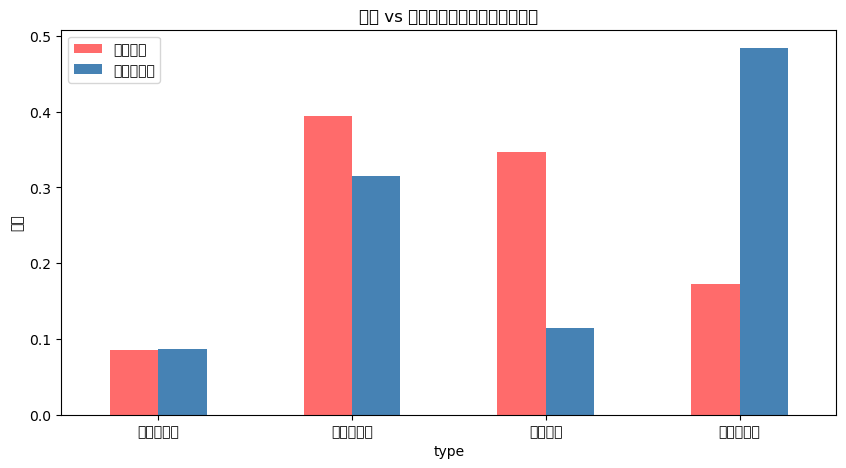

In [14]:
# 直播时段内，针对每个用户，看他的行为组合
live_users = df[df['is_live_hour']].groupby('user_id')['behavior']\
    .apply(set).reset_index()
live_users.columns = ['user_id', 'behaviors']

def user_type(behaviors):
    if 'buy' in behaviors:
        if 'cart' not in behaviors and 'fav' not in behaviors:
            return '冲动购买型'   # 直接买
        else:
            return '计划购买型'   # 经过加购/收藏再买
    elif 'cart' in behaviors or 'fav' in behaviors:
        return '种草未购型'       # 加购或收藏但没买
    else:
        return '纯浏览型'         # 只看不买

live_users['type'] = live_users['behaviors'].apply(user_type)
non_live_users['type'] = non_live_users['behaviors'].apply(user_type)

all_users = pd.concat([live_users, non_live_users]).drop_duplicates('user_id')

# 各类型占比
type_dist = live_users['type'].value_counts(normalize=True)
print(type_dist)

# 对比非直播时段
non_live_users = df[~df['is_live_hour']].groupby('user_id')['behavior']\
    .apply(set).reset_index()
non_live_users.columns = ['user_id', 'behaviors']
non_live_users['type'] = non_live_users['behaviors'].apply(user_type)

non_live_dist = non_live_users['type'].value_counts(normalize=True)

# 对比可视化
compare = pd.DataFrame({
    '直播时段': type_dist,
    '非直播时段': non_live_dist
})
compare.plot(kind='bar', figsize=(10,5), title='直播 vs 非直播时段用户行为结构对比',color=['#FF6B6B', 'steelblue'])
plt.xticks(rotation=0)
plt.ylabel('占比')
plt.savefig('output/charts/user_type_compare.png')

### 📊 发现：流量结构差异导致转化率悖论

直播时段整体转化率（26.3%）低于非直播时段（57.3%），但这并不意味着直播效果差。

用户结构分析揭示了真正原因：直播时段纯浏览用户占比高达 34.7%，
大量围观流量将分母撑大，稀释了整体转化率。
用户行为呈现"要么直接买、要么直接走"的两极化特征，中间态（加购/收藏）用户占比显著减少。

> 直播有效吸引了冲动型买家，但同时带来了大量围观流量，单以整体转化率衡量直播效果存在结构性低估。

### 0105 验证"种草未购型"的滞后转化

直播时段加购/收藏但没买的用户，有没有在后续时段完成购买？

In [7]:
# 直播时段有cart/fav但没buy的用户
live_cart_fav = live_users[live_users['type']=='种草未购型']['user_id']

# 这些用户在非直播时段有没有buy
delayed = df[
    df['user_id'].isin(live_cart_fav) & 
    ~df['is_live_hour'] & 
    (df['behavior']=='buy')
]['user_id'].nunique()

print(f'种草未购用户数: {len(live_cart_fav)}')
print(f'其中后续完成购买的: {delayed}')
print(f'滞后转化率: {delayed/len(live_cart_fav):.1%}')

种草未购用户数: 3405
其中后续完成购买的: 1946
滞后转化率: 57.2%


### 📊 发现：直播蓄水效应显著

直播时段种草未购用户（加购或收藏但未下单）共 **3,405人**，其中 **57.2%** 在后续时段完成了购买。
这部分滞后转化是可归因回直播的隐性贡献，若不引入跨时段归因，直播效果将被严重低估。

> 直播的核心价值在于"冲动转化 + 种草蓄水"的双重机制，而非即时转化率的提升。

### 🔖 模块小结

| 指标 | 直播时段 | 非直播时段 |
|---|---|---|
| 冲动购买率 | 51.8% | 47.1% |
| 整体转化率 | 26.3% | 57.3% |
| 纯浏览用户占比 | 34.7% | — |
| 种草后滞后转化率 | 57.2% | — |

直播时段冲动购买率更高，但大量围观流量稀释了整体转化率；
超过一半的种草用户在后续时段完成了购买，直播的蓄水效应不可忽视。
**单一即时转化率不足以衡量直播的真实带货效果。**

---

## 模块二：转化漏斗分析

**分析目的**

对比直播时段与非直播时段在各转化节点的流失情况，
定位直播场景下用户流失的关键断点，
并分析加购未购用户的后续行为，量化直播的滞后转化效应。

**核心指标**
- 浏览→加购转化率
- 加购→购买转化率
- 浏览→购买转化率（整体）
- 收藏→购买转化率
- 滞后转化率：直播时段加购未购用户中，后续完成购买的比例

C:\Windows\Temp\ipykernel_6124\175002924.py:24: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from current font.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_6124\175002924.py:24: UserWarning: Glyph 25773 (\N{CJK UNIFIED IDEOGRAPH-64AD}) missing from current font.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_6124\175002924.py:24: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_6124\175002924.py:24: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from current font.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_6124\175002924.py:24: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from current font.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_6124\175002924.py:24: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_6124\175002924.py:24: UserWarning: Glyph 28431 (\N

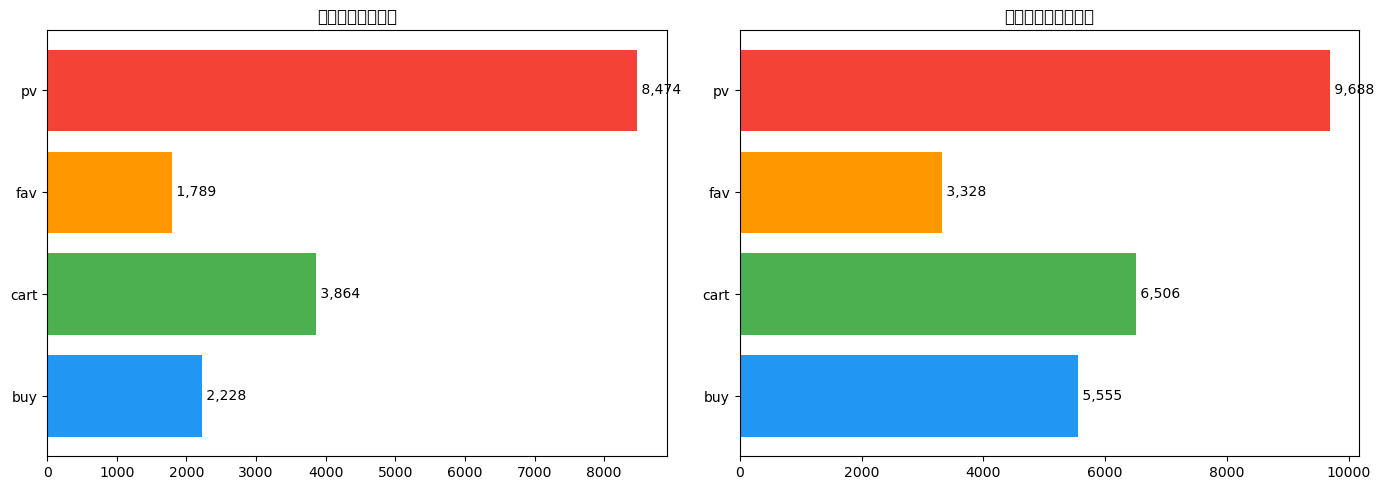

In [8]:
# 统计各行为的用户数
behaviors = ['pv', 'fav', 'cart', 'buy']

def funnel_data(data):
    return {b: data[data['behavior']==b]['user_id'].nunique() 
            for b in behaviors}

live_funnel = funnel_data(df[df['is_live_hour']])
normal_funnel = funnel_data(df[~df['is_live_hour']])

# 可视化漏斗对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (funnel, title) in zip(axes, 
    [(live_funnel, '直播时段转化漏斗'), 
     (normal_funnel, '非直播时段转化漏斗')]):
    
    values = [funnel[b] for b in behaviors]
    ax.barh(behaviors[::-1], values[::-1], color=['#2196F3','#4CAF50','#FF9800','#F44336'])
    ax.set_title(title)
    for i, v in enumerate(values[::-1]):
        ax.text(v, i, f' {v:,}', va='center')

plt.tight_layout()
plt.savefig('output/charts/funnel_comparison.png')

### 📊 发现：流失发生在转化链路内部，而非入口流量不足

直播时段pv用户（8,474人）仅比非直播时段（9,688人）少14%，
但最终购买用户（2,228人 vs 5,555人）差距高达60%。

入口流量相近，但购买结果差距悬殊，说明流失发生在转化链路的每个环节，而非用户进入量不足。

此外，直播时段fav用户仅为非直播时段的54%，cart用户仅为59%，
用户连"收藏/加购"这一中间动作都更少做,
要么直接买，要么直接走，与冲动消费的两极化特征完全吻合。

In [9]:
def funnel_data(data):
    return {b: data[data['behavior']==b]['user_id'].nunique() 
            for b in ['pv', 'fav', 'cart', 'buy']}

live_funnel = funnel_data(df[df['is_live_hour']])
normal_funnel = funnel_data(df[~df['is_live_hour']])

live_pv_to_cart = live_funnel['cart'] / live_funnel['pv'] if live_funnel['pv'] > 0 else 0
normal_pv_to_cart = normal_funnel['cart'] / normal_funnel['pv'] if normal_funnel['pv'] > 0 else 0

live_cart_to_buy = live_funnel['buy'] / live_funnel['cart'] if live_funnel['cart'] > 0 else 0
normal_cart_to_buy = normal_funnel['buy'] / normal_funnel['cart'] if normal_funnel['cart'] > 0 else 0

live_pv_to_buy = live_funnel['buy'] / live_funnel['pv'] if live_funnel['pv'] > 0 else 0
normal_pv_to_buy = normal_funnel['buy'] / normal_funnel['pv'] if normal_funnel['pv'] > 0 else 0

fav_users = set(df[df['is_live_hour'] & (df['behavior']=='fav')]['user_id'])
buy_users = set(df[df['is_live_hour'] & (df['behavior']=='buy')]['user_id'])

live_fav_to_buy = len(fav_users & buy_users) / len(fav_users) if fav_users else 0

fav_users_n = set(df[~df['is_live_hour'] & (df['behavior']=='fav')]['user_id'])
buy_users_n = set(df[~df['is_live_hour'] & (df['behavior']=='buy')]['user_id'])

normal_fav_to_buy = len(fav_users_n & buy_users_n) / len(fav_users_n) if fav_users_n else 0


### 📊 发现：直播时段每个转化节点流失更严重

四项转化指标在直播时段全面低于非直播时段，且差距随转化链路推进而扩大。
流失并非集中在某一环节，而是在每个决策节点持续累积。

| 指标 | 直播时段 | 非直播时段 | 差异 |
|---|---|---|---|
| 浏览→加购 | 45.6% | 67.2% | -21.6% |
| 加购→购买 | 57.7% | 85.4% | -27.7% |
| 浏览→购买 | 26.3% | 57.3% | -31.1% |
| 收藏→购买 | 29.6% | 62.4% | -32.8% |

其中**加购→购买断点最为显著（-27.7%）**，是后续重点分析的流失节点。

In [24]:
print("\n{:<20} {:>17} {:>10} {:>8}".format("指标", "直播时段", "非直播时段", "差异"))
print("-"*65)
print("{:<20} {:>14.2%} {:>14.2%} {:>14.2%}".format("浏览→加购转化率", live_pv_to_cart, normal_pv_to_cart, live_pv_to_cart - normal_pv_to_cart))
print("{:<20} {:>14.2%} {:>14.2%} {:>14.2%}".format("加购→购买转化率", live_cart_to_buy, normal_cart_to_buy, live_cart_to_buy - normal_cart_to_buy))
print("{:<20} {:>14.2%} {:>14.2%} {:>14.2%}".format("浏览→购买转化率", live_pv_to_buy, normal_pv_to_buy, live_pv_to_buy - normal_pv_to_buy))
print("{:<20} {:>14.2%} {:>14.2%} {:>14.2%}".format("收藏→购买转化率", live_fav_to_buy, normal_fav_to_buy, live_fav_to_buy - normal_fav_to_buy))



指标                                直播时段      非直播时段       差异
-----------------------------------------------------------------
浏览→加购转化率                     45.60%         67.16%        -21.56%
加购→购买转化率                     57.66%         85.38%        -27.72%
浏览→购买转化率                     26.29%         57.34%        -31.05%
收藏→购买转化率                     29.63%         62.44%        -32.81%


### 0201分用户类型的漏斗断点分析

##### 各节点的绝对流失人数对比

In [11]:
print("用户数规模对比：")
for behavior in ['pv', 'fav', 'cart', 'buy']:
    print(f"{behavior}: 直播={live_funnel[behavior]:,}  非直播={normal_funnel[behavior]:,}")

用户数规模对比：
pv: 直播=8,474  非直播=9,688
fav: 直播=1,789  非直播=3,328
cart: 直播=3,864  非直播=6,506
buy: 直播=2,228  非直播=5,555


##### 找出流失发生在哪个时段

In [12]:
# 直播时段加购、但从未购买的用户
live_cart_users = set(df[df['is_live_hour'] & (df['behavior']=='cart')]['user_id'])
live_buy_users = set(df[df['is_live_hour'] & (df['behavior']=='buy')]['user_id'])

# 直播时段加购但未在直播时段购买的用户
cart_not_buy_live = live_cart_users - live_buy_users

# 这批人在非直播时段的行为
subsequent = df[
    df['user_id'].isin(cart_not_buy_live) & 
    ~df['is_live_hour']
]['behavior'].value_counts()

print("直播时段加购未购用户的后续行为：")
print(subsequent)

# 其中最终完成购买的比例
delayed_buyers = df[
    df['user_id'].isin(cart_not_buy_live) & 
    ~df['is_live_hour'] & 
    (df['behavior']=='buy')
]['user_id'].nunique()

print(f"\n最终滞后购买人数: {delayed_buyers}")
print(f"滞后转化率: {delayed_buyers/len(cart_not_buy_live):.1%}")
print(f"彻底流失率: {1 - delayed_buyers/len(cart_not_buy_live):.1%}")

直播时段加购未购用户的后续行为：
behavior
pv      187567
cart     15488
fav       4510
buy       3895
Name: count, dtype: int64

最终滞后购买人数: 1540
滞后转化率: 58.6%
彻底流失率: 41.4%


### 📊 发现：加购未购用户超半数实现滞后转化，彻底流失用户仍在平台活跃

直播时段加购未购用户中：
- **58.6%** 在后续时段完成了购买，属于可归因回直播的隐性贡献
- **41.4%** 彻底流失，但后续产生了 187,567 次浏览行为，说明这批人仍在平台活跃

> 彻底流失用户并非真正离开平台，而是没有回来完成这件商品的购买。
> 他们是高潜力触达人群，次日定向触达的转化成功率理论上较高。

##### 结合用户分类，找每类用户的漏斗断点

       浏览→加购  加购→购买  浏览→购买
用户类型                      
种草未购型  86.6%  60.0%  52.0%
纯浏览型   53.0%  89.7%  47.5%


C:\Windows\Temp\ipykernel_6124\2469864966.py:28: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from current font.
  plt.savefig('output/charts/funnel_by_usertype.png')
C:\Windows\Temp\ipykernel_6124\2469864966.py:28: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  plt.savefig('output/charts/funnel_by_usertype.png')
C:\Windows\Temp\ipykernel_6124\2469864966.py:28: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.savefig('output/charts/funnel_by_usertype.png')
C:\Windows\Temp\ipykernel_6124\2469864966.py:28: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  plt.savefig('output/charts/funnel_by_usertype.png')
C:\Windows\Temp\ipykernel_6124\2469864966.py:28: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.
  plt.savefig('output/charts/funnel_by_usertype.png')
C:\Windows\Temp\ipykernel_6124\2469864966.py:28: UserWarning

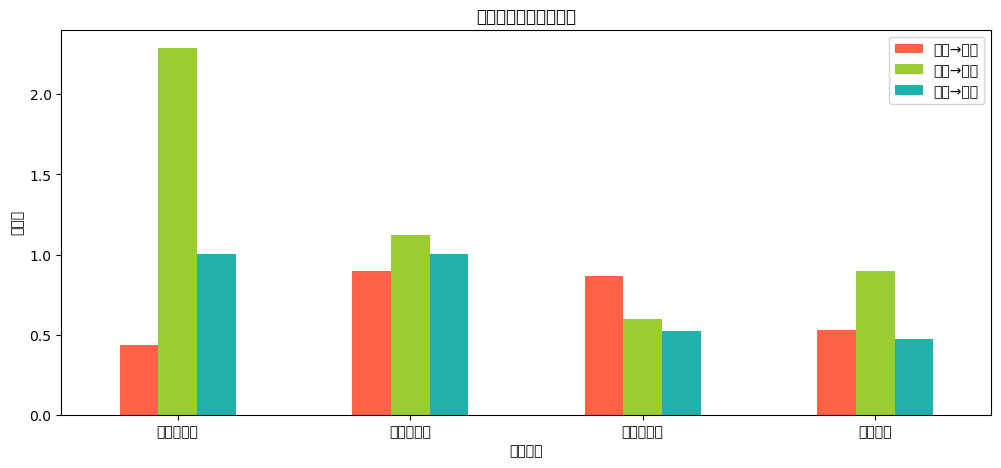

In [15]:
user_type_map = all_users.set_index('user_id')['type']
df['user_type'] = df['user_id'].map(user_type_map)

results = []
for utype in ['冲动购买型', '计划购买型', '种草未购型', '纯浏览型']:
    sub = df[df['user_type'] == utype]
    pv = sub[sub['behavior']=='pv']['user_id'].nunique()
    cart = sub[sub['behavior']=='cart']['user_id'].nunique()
    fav = sub[sub['behavior']=='fav']['user_id'].nunique()
    buy = sub[sub['behavior']=='buy']['user_id'].nunique()
    
    results.append({
        '用户类型': utype,
        '浏览→加购': cart/pv if pv else 0,
        '加购→购买': buy/cart if cart else 0,
        '浏览→购买': buy/pv if pv else 0,
    })

result_df = pd.DataFrame(results).set_index('用户类型')

valid_types = ['种草未购型', '纯浏览型']
print(result_df.loc[valid_types].map(lambda x: f'{x:.1%}'))

# 可视化
result_df.plot(kind='bar', figsize=(12,5), title='各类用户转化漏斗对比',color=['tomato','yellowgreen','lightseagreen'])
plt.xticks(rotation=0)
plt.ylabel('转化率')
plt.savefig('output/charts/funnel_by_usertype.png')

### 📊 发现：种草未购型用户流失集中在决策最后一环

- 种草未购型用户浏览→加购转化率高达86.6%，说明这类用户对商品有明确兴趣；但加购→购买转化率仅60.0%，流失集中在决策的最后一步。
               
- 结合模块一中57.2%的滞后转化率，这类用户并非真正放弃购买，而是需要一个外部触发
>限时优惠或库存紧张提醒是最直接有效的干预手段。

### 🔖 模块二小结

直播时段四项转化指标全面低于非直播时段，但流失结构呈现两个关键特征：

1. **入口流量差距（14%）远小于购买结果差距（60%）**，流失在链路内部逐层累积
2. **加购未购用户中58.6%实现滞后转化**，41.4%彻底流失但仍在平台活跃，具备触达价值

种草未购型用户的断点定位在加购→购买环节，
是设计次日触达策略的核心目标人群。

---

## 模块三：RFM用户分层与聚类

**分析目的**

对有购买记录的用户进行RFM建模与KMeans聚类，
识别平台用户的价值分层；
并将直播时段种草未购用户与RFM结果交叉分析，
明确流失用户的价值构成，为触达运营提供优先级依据。

**RFM指标定义**
- R（Recency）：距数据集截止日期最近一次购买的天数，越小越好
- F（Frequency）：购买总次数，越大越好
- M（Monetary）：购买商品的品类数量，以品类数代替消费金额，越大越好

**聚类结果**

| 簇 | R均值 | F均值 | M均值 | 用户标签 |
|---|---|---|---|---|
| 簇2 | 1.4 | 38.1 | 28.7 | 高价值核心用户 |
| 簇3 | 2.0 | 7.8 | 6.5 | 成长型用户 |
| 簇0 | 2.0 | 2.3 | 2.1 | 新用户/低频用户 |
| 簇1 | 6.0 | 1.6 | 1.5 | 流失风险用户 |

In [16]:
pip install -U threadpoolctl

Note: you may need to restart the kernel to use updated packages.


### 0301 RFM聚类分析

C:\Windows\Temp\ipykernel_6124\3750781924.py:32: UserWarning: Glyph 32920 (\N{CJK UNIFIED IDEOGRAPH-8098}) missing from current font.
  plt.savefig('output/charts/elbow.png')
C:\Windows\Temp\ipykernel_6124\3750781924.py:32: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.savefig('output/charts/elbow.png')
C:\Windows\Temp\ipykernel_6124\3750781924.py:32: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from current font.
  plt.savefig('output/charts/elbow.png')
C:\Windows\Temp\ipykernel_6124\3750781924.py:32: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from current font.
  plt.savefig('output/charts/elbow.png')
C:\Windows\Temp\ipykernel_6124\3750781924.py:32: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.savefig('output/charts/elbow.png')
C:\Windows\Temp\ipykernel_6124\3750781924.py:32: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from curre

                R          F          M
cluster                                
0        2.044048   2.328869   2.090774
1        5.956419   1.599716   1.458077
2        1.428571  38.071429  28.714286
3        2.045220   7.776486   6.496124


D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32920 (\N{CJK UNIFIED IDEOGRAPH-8098}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabt

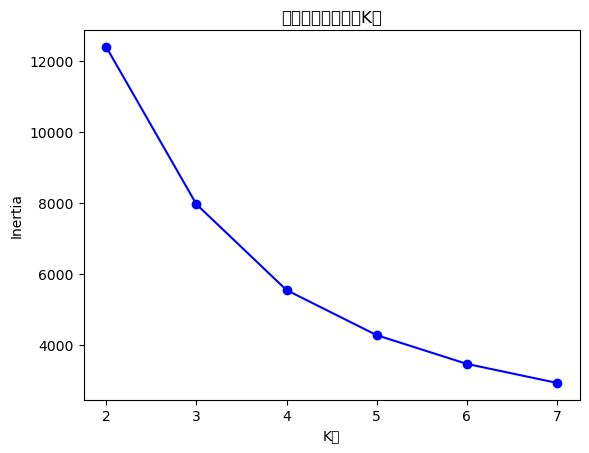

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 只取有购买行为的用户
buy_df = df[df['behavior'] == 'buy'].copy()

# 构造RFM指标
reference_date = pd.Timestamp('2017-12-04')

rfm = buy_df.groupby('user_id').agg(
    R=('datetime', lambda x: (reference_date - x.max()).days),
    F=('item_id', 'count'),
    M=('category_id', 'nunique')   # 用购买品类数代替消费金额
).reset_index()

# 标准化
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['R', 'F', 'M']])

# K-Means聚类（先用肘部法确定K值）
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 8), inertias, 'bo-')
plt.xlabel('K值')
plt.ylabel('Inertia')
plt.title('肘部法则确定最优K值')
plt.savefig('output/charts/elbow.png')

# 用K=4聚类
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km.fit_predict(rfm_scaled)

# 分析各簇特征
cluster_summary = rfm.groupby('cluster')[['R','F','M']].mean()
print(cluster_summary)

### 📊 用户分层结果

基于K-Means聚类（K=4）将有购买记录的用户分为四类：

| 簇 | R均值 | F均值 | M均值 | 用户标签 | 特征描述 |
|---|---|---|---|---|---|
| 簇2 | 1.4 | 38.1 | 28.7 | **高价值核心用户** | 最近购买、频次极高、品类极广，平台最重要的用户群 |
| 簇3 | 2.0 | 7.8 | 6.5 | **成长型用户** | 近期活跃、中等频次，有潜力向高价值转化 |
| 簇0 | 2.0 | 2.3 | 2.1 | **新用户/低频用户** | R值较近但频次低，可能是新用户或偶发购买用户 |
| 簇1 | 6.0 | 1.6 | 1.5 | **流失风险用户** | R值最大，长期未购买，频次极低，濒临流失 |

> 注：R值越小代表越近期购买，F和M值越大代表购买频次和品类广度越高。

### 0302 各簇用户在直播时段的购买占比

In [18]:
label_map = {
    2: '高价值核心用户',
    3: '成长型用户',
    0: '新用户/低频用户',
    1: '流失风险用户'
}

rfm_labels = rfm[['user_id', 'cluster']]
df = df.merge(rfm_labels, on='user_id', how='left')

cluster_live = df[df['behavior']=='buy'].groupby('cluster')['is_live_hour']\
    .mean().reset_index()
cluster_live['label'] = cluster_live['cluster'].map(label_map)
cluster_live.columns = ['cluster', '直播时段购买占比', 'label']
print(cluster_live.sort_values('直播时段购买占比', ascending=False))

   cluster  直播时段购买占比     label
0      0.0  0.215591  新用户/低频用户
1      1.0  0.213799    流失风险用户
3      3.0  0.188403     成长型用户
2      2.0  0.172608   高价值核心用户


### 0303 种草未购用户的簇分布

In [19]:
# 重新定义live_cart_not_buy
live_cart_users = set(df[df['is_live_hour'] & (df['behavior']=='cart')]['user_id'])
live_buy_users = set(df[df['is_live_hour'] & (df['behavior']=='buy')]['user_id'])
live_cart_not_buy = live_cart_users - live_buy_users

In [20]:
# 只取user_id列，避免cluster列冲突
lost_cluster = df[df['user_id'].isin(live_cart_not_buy)]\
    .drop_duplicates('user_id')[['user_id']]\
    .merge(rfm[['user_id','cluster']], on='user_id', how='left')

lost_cluster['cluster_label'] = lost_cluster['cluster']\
    .map(label_map)\
    .fillna('从未购买用户')

lost_dist = lost_cluster['cluster_label'].value_counts(normalize=True)
print("种草未购用户的分布：")
print(lost_dist)

种草未购用户的分布：
cluster_label
从未购买用户      0.413557
新用户/低频用户    0.293222
流失风险用户      0.235339
成长型用户       0.057883
Name: proportion, dtype: float64


### 📊 发现：种草未购用户以低价值和未转化用户为主

直播时段种草未购用户（2,626人）的RFM分布：

| 用户类型 | 占比 | 核心特征 | 触达策略 |
|---|---|---|---|
| 从未购买用户 | 41.4% | 被直播吸引至加购，但从未完成首购 | 首购专属优惠券，降低首单门槛 |
| 新用户/低频用户 | 29.3% | 购买意愿弱，直播激活至加购已是突破 | 限时库存提醒，制造紧迫感 |
| 流失风险用户 | 23.5% | 老用户被直播唤醒，差临门一脚 | 次日定向优惠券召回，性价比最高 |
| 成长型用户 | 5.8% | 购买频次不低，可能只是延迟决策 | push通知提醒，成本最低 |

> 流失风险用户（23.5%）虽非占比最大，但召回价值最高——
> 他们曾是平台活跃用户，被直播重新激活了购买兴趣，只需一个低成本触发即可转化。

### 🔖 模块三小结

RFM聚类将用户分为四层，与直播种草未购用户交叉分析后发现：

- 种草未购用户中 **41.4% 从未在平台购买过**，直播是拉新的有效渠道，但首购转化是最大断点
- **流失风险用户（23.5%）召回价值最高**，次日定向优惠券是成本效益最优的触达方式
- 不同用户类型需要差异化的触达策略，统一运营会造成资源浪费

结合前两个模块的发现，直播带货的完整价值链条为：
**拉新曝光 → 冲动转化 → 种草蓄水 → 分层触达召回**

---